In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import quantum_algorithms as qa

In [2]:
# Experiment settings

shots = 1024
n_values = [1, 3, 5, 7, 9]
theta_values = np.radians(np.arange(0, 181, 10))

axes = {
    "X": (1, 0, 0),
    "Y": (0, 1, 0),
    "Z": (0, 0, 1),
}

functions = {
    "constant_1": qa.deutsch_jozsa.f_constant_1,
    "constant_0": qa.deutsch_jozsa.f_constant_0,
    "balanced": qa.deutsch_jozsa.f_balanced_parity,
}

error_positions = {
    "E1_before_H": qa.deutsch_jozsa.deutsch_jozsa_error1,
    "E2_after_first_H": qa.deutsch_jozsa.deutsch_jozsa_error2,
    "E3_after_oracle": qa.deutsch_jozsa.deutsch_jozsa_error3,
    "E4_after_final_H": qa.deutsch_jozsa.deutsch_jozsa_error4,
}

In [3]:
# Run simulation with shot

results = []
for n in n_values:
    print("Running n =", n)

    target_qubit = n // 2

    for function_name, f in functions.items():

        # Original DJA without error
        state_ref = qa.deutsch_jozsa.deutsch_jozsa(n, f)
        samples_ref = qa.deutsch_jozsa.sample_measurements_input(
            state_ref, n, shots
        )

        P0_ref = samples_ref[0] / shots

        for theta in theta_values:
            for axis_name, axis in axes.items():

                results.append({
                    "n": n,
                    "theta_rad": theta,
                    "theta_deg": np.degrees(theta),
                    "axis": axis_name,
                    "target_qubit": target_qubit,
                    "function": function_name,
                    "error_position": "no_error",
                    "P0": P0_ref,
                    "shots": shots,
                })

                # E1, E2, E3, E4
                for error_name, error_function in error_positions.items():

                    state_error = error_function(
                        n, f, theta, target_qubit, axis
                    )

                    samples_error = qa.deutsch_jozsa.sample_measurements_input(
                        state_error, n, shots
                    )

                    P0_error = samples_error[0] / shots

                    results.append({
                        "n": n,
                        "theta_rad": theta,
                        "theta_deg": np.degrees(theta),
                        "axis": axis_name,
                        "target_qubit": target_qubit,
                        "function": function_name,
                        "error_position": error_name,
                        "P0": P0_error,
                        "shots": shots,
                    })

df = pd.DataFrame(results)

df.head()

Running n = 1
Running n = 3
Running n = 5
Running n = 7
Running n = 9


,n,theta_rad,theta_deg,axis,target_qubit,function,error_position,P0,shots
0,1,0.0,0.0,X,0,constant_1,no_error,1.0,1024
1,1,0.0,0.0,X,0,constant_1,E1_before_H,1.0,1024
2,1,0.0,0.0,X,0,constant_1,E2_after_first_H,1.0,1024
3,1,0.0,0.0,X,0,constant_1,E3_after_oracle,1.0,1024
4,1,0.0,0.0,X,0,constant_1,E4_after_final_H,1.0,1024


In [4]:
# Save results
df.to_csv("dja_error_results_shots_1024.csv", index=False)

In [48]:
def plot_error_positions(df, n_plot, axis_plot, function_plot):

    plot_df = df[
        (df["n"] == n_plot) &
        (df["axis"] == axis_plot) &
        (df["function"] == function_plot)
    ]

    plt.figure(figsize=(8, 5), dpi=150)

    axis = axis_plot.upper()

    labels = {
        "no_error": "Ideal circuit",
        "E1_before_H": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_1$",
        "E2_after_first_H": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_2$",
        "E3_after_oracle": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_3$",
        "E4_after_final_H": rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at $E_4$",
    }

    for error_pos, label in labels.items():

        subset = plot_df[plot_df["error_position"] == error_pos]

        if subset.empty:
            continue

        plt.plot(
            subset["theta_deg"],
            subset["P0"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=label
        )

    
    plt.xlabel(r"Rotation angle $\theta$ (degrees)", fontsize=13)
    plt.ylabel(r"Probability $P(0\ldots0)$", fontsize=13)

    plt.title(
    rf"Deutsch--Jozsa under $R_{{{axis_plot}}}(\theta)$ Errors"
    "\n"
    rf"Parity = {function_plot}",
    fontsize=14
)
    
    if function_plot in ["constant_0", "constant_1"]:
        plt.ylim(0, 1.05)
    else:
        plt.ylim(-0.1, 1.05)

    plt.xlim(0, 180)

    plt.legend(
    fontsize=12,
    loc="upper right"
)

    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    filename = (
    f"DJA_RX_errors_"
    f"{axis_plot}_"
    f"{function_plot}_"
    f"n{n_plot}.pdf"
)

    plt.savefig(
    filename,
    bbox_inches="tight"
)
    plt.show()

In [67]:
report_tables = df_q[df_q["n"] == 9]

In [68]:
summary = report_table.copy()

summary["Value"] = (
    summary["Max_Sensitivity"].round(3).astype(str)
    + " ("
    + summary["Mean_Sensitivity"].round(3).astype(str)
    + ")"
)

final_table = summary.pivot(
    index="Error Location",
    columns="axis",
    values="Value"
)

print(final_table)

axis                      X            Y            Z
Error Location                                       
E1              1.0 (0.501)  1.0 (0.499)    0.0 (0.0)
E2                0.0 (0.0)  1.0 (0.501)  1.0 (0.501)
E3                0.0 (0.0)    1.0 (0.5)  1.0 (0.497)
E4              1.0 (0.498)  1.0 (0.501)    0.0 (0.0)


In [69]:
table = report_table.pivot(
    index="Error Location",
    columns="axis",
    values="Max_Sensitivity"
)

print(table)

axis              X    Y    Z
Error Location               
E1              1.0  1.0  0.0
E2              0.0  1.0  1.0
E3              0.0  1.0  1.0
E4              1.0  1.0  0.0


In [70]:
mean_table = report_table.pivot(
    index="Error Location",
    columns="axis",
    values="Mean_Sensitivity"
)

print(mean_table)

axis                   X         Y         Z
Error Location                              
E1              0.500771  0.498972  0.000000
E2              0.000000  0.500925  0.500565
E3              0.000000  0.499692  0.497327
E4              0.497738  0.501439  0.000000


In [71]:
report_table = sensitivity_table[
    (sensitivity_table["n"] == 9) &
    (sensitivity_table["function"] == "constant_1")
]

print(report_table)

     n    function axis Error Location  Max_Sensitivity  Mean_Sensitivity
168  9  constant_1    X             E1              1.0          0.500771
169  9  constant_1    X             E2              0.0          0.000000
170  9  constant_1    X             E3              0.0          0.000000
171  9  constant_1    X             E4              1.0          0.497738
172  9  constant_1    Y             E1              1.0          0.498972
173  9  constant_1    Y             E2              1.0          0.500925
174  9  constant_1    Y             E3              1.0          0.499692
175  9  constant_1    Y             E4              1.0          0.501439
176  9  constant_1    Z             E1              0.0          0.000000
177  9  constant_1    Z             E2              1.0          0.500565
178  9  constant_1    Z             E3              1.0          0.497327
179  9  constant_1    Z             E4              0.0          0.000000


In [73]:
report_table = sensitivity_table[
    (sensitivity_table["n"] == 9) &
    (sensitivity_table["function"] == "constant_0")
]

print(report_table)

     n    function axis Error Location  Max_Sensitivity  Mean_Sensitivity
156  9  constant_0    X             E1              1.0          0.501439
157  9  constant_0    X             E2              0.0          0.000000
158  9  constant_0    X             E3              0.0          0.000000
159  9  constant_0    X             E4              1.0          0.500308
160  9  constant_0    Y             E1              1.0          0.502519
161  9  constant_0    Y             E2              1.0          0.499846
162  9  constant_0    Y             E3              1.0          0.499846
163  9  constant_0    Y             E4              1.0          0.493832
164  9  constant_0    Z             E1              0.0          0.000000
165  9  constant_0    Z             E2              1.0          0.497636
166  9  constant_0    Z             E3              1.0          0.500822
167  9  constant_0    Z             E4              0.0          0.000000


In [74]:
report_table = sensitivity_table[
    (sensitivity_table["n"] == 9) &
    (sensitivity_table["function"] == "balanced")
]

print(report_table)

     n  function axis Error Location  Max_Sensitivity  Mean_Sensitivity
144  9  balanced    X             E1              0.0               0.0
145  9  balanced    X             E2              0.0               0.0
146  9  balanced    X             E3              0.0               0.0
147  9  balanced    X             E4              0.0               0.0
148  9  balanced    Y             E1              0.0               0.0
149  9  balanced    Y             E2              0.0               0.0
150  9  balanced    Y             E3              0.0               0.0
151  9  balanced    Y             E4              0.0               0.0
152  9  balanced    Z             E1              0.0               0.0
153  9  balanced    Z             E2              0.0               0.0
154  9  balanced    Z             E3              0.0               0.0
155  9  balanced    Z             E4              0.0               0.0


In [56]:
# ==============================
# Quantitative Analysis Tables
# ==============================

import os

output_dir = "quantitative_tables"
os.makedirs(output_dir, exist_ok=True)

# Add ideal reference probability
ideal_df = df[df["error_position"] == "no_error"][
    ["n", "theta_deg", "axis", "function", "P0"]
].rename(columns={"P0": "P0_ideal"})

df_q = df.merge(
    ideal_df,
    on=["n", "theta_deg", "axis", "function"],
    how="left"
)

# Remove ideal circuit rows
df_q = df_q[df_q["error_position"] != "no_error"].copy()

# Sensitivity
df_q["Sensitivity"] = abs(df_q["P0"] - df_q["P0_ideal"])

# Percentage performance loss
df_q["Performance_Loss_%"] = (
    (df_q["P0_ideal"] - df_q["P0"]) / df_q["P0_ideal"]
) * 100

# Avoid problems when ideal probability is 0, e.g. balanced function
df_q["Performance_Loss_%"] = df_q["Performance_Loss_%"].replace(
    [np.inf, -np.inf], np.nan
)

# Shorter names for report
name_map = {
    "E1_before_H": "E1",
    "E2_after_first_H": "E2",
    "E3_after_oracle": "E3",
    "E4_after_final_H": "E4",
}
df_q["Error Location"] = df_q["error_position"].map(name_map)

In [57]:
sensitivity_table = (
    df_q
    .groupby(["n", "function", "axis", "Error Location"])
    .agg(
        Max_Sensitivity=("Sensitivity", "max"),
        Mean_Sensitivity=("Sensitivity", "mean")
    )
    .reset_index()
)

sensitivity_table.to_csv(
    f"{output_dir}/sensitivity_table.csv",
    index=False
)

print(sensitivity_table)

     n    function axis Error Location  Max_Sensitivity  Mean_Sensitivity
0    1    balanced    X             E1              1.0          0.499589
1    1    balanced    X             E2              0.0          0.000000
2    1    balanced    X             E3              0.0          0.000000
3    1    balanced    X             E4              1.0          0.501079
4    1    balanced    Y             E1              1.0          0.501234
..  ..         ...  ...            ...              ...               ...
175  9  constant_1    Y             E4              1.0          0.501439
176  9  constant_1    Z             E1              0.0          0.000000
177  9  constant_1    Z             E2              1.0          0.500565
178  9  constant_1    Z             E3              1.0          0.497327
179  9  constant_1    Z             E4              0.0          0.000000

[180 rows x 6 columns]


In [58]:
loss_table = (
    df_q
    .groupby(["n", "function", "axis", "Error Location"])
    .agg(
        Max_Loss_Percent=("Performance_Loss_%", "max"),
        Mean_Loss_Percent=("Performance_Loss_%", "mean")
    )
    .reset_index()
)

loss_table.to_csv(
    f"{output_dir}/performance_loss_table.csv",
    index=False
)

print(loss_table)

     n    function axis Error Location  Max_Loss_Percent  Mean_Loss_Percent
0    1    balanced    X             E1               NaN                NaN
1    1    balanced    X             E2               NaN                NaN
2    1    balanced    X             E3               NaN                NaN
3    1    balanced    X             E4               NaN                NaN
4    1    balanced    Y             E1               NaN                NaN
..  ..         ...  ...            ...               ...                ...
175  9  constant_1    Y             E4             100.0          50.143914
176  9  constant_1    Z             E1               0.0           0.000000
177  9  constant_1    Z             E2             100.0          50.056538
178  9  constant_1    Z             E3             100.0          49.732730
179  9  constant_1    Z             E4               0.0           0.000000

[180 rows x 6 columns]


In [60]:
from matplotlib.backends.backend_pdf import PdfPages

def save_table_to_pdf(table, title, pdf):
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis("off")

    ax.set_title(title, fontsize=14, fontweight="bold", pad=20)

    table_display = table.round(4)

    tbl = ax.table(
        cellText=table_display.values,
        colLabels=table_display.columns,
        loc="center",
        cellLoc="center"
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.5)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)


pdf_path = f"{output_dir}/quantitative_analysis_tables.pdf"

with PdfPages(pdf_path) as pdf:
    save_table_to_pdf(
        sensitivity_table,
        "Sensitivity Analysis Table",
        pdf
    )

    save_table_to_pdf(
        fixed_angle_table,
        "Performance Comparison at θ = 90°",
        pdf
    )

    save_table_to_pdf(
        loss_table,
        "Percentage Performance Loss Table",
        pdf
    )

print("PDF saved as:", pdf_path)

PDF saved as: quantitative_tables/quantitative_analysis_tables.pdf


In [54]:
fixed_angle = 90

fixed_angle_table = df_q[
    df_q["theta_deg"] == fixed_angle
][
    ["n", "function", "axis", "Error Location", "P0", "Sensitivity"]
]

fixed_angle_table.to_csv(
    f"{output_dir}/fixed_angle_90deg_table.csv",
    index=False
)

print(fixed_angle_table)

      n    function axis Error Location        P0  Sensitivity
136   1  constant_1    X             E1  0.484375     0.515625
137   1  constant_1    X             E2  1.000000     0.000000
138   1  constant_1    X             E3  1.000000     0.000000
139   1  constant_1    X             E4  0.493164     0.506836
141   1  constant_1    Y             E1  0.496094     0.503906
...  ..         ...  ...            ...       ...          ...
4134  9    balanced    Y             E4  0.000000     0.000000
4136  9    balanced    Z             E1  0.000000     0.000000
4137  9    balanced    Z             E2  0.000000     0.000000
4138  9    balanced    Z             E3  0.000000     0.000000
4139  9    balanced    Z             E4  0.000000     0.000000

[180 rows x 6 columns]


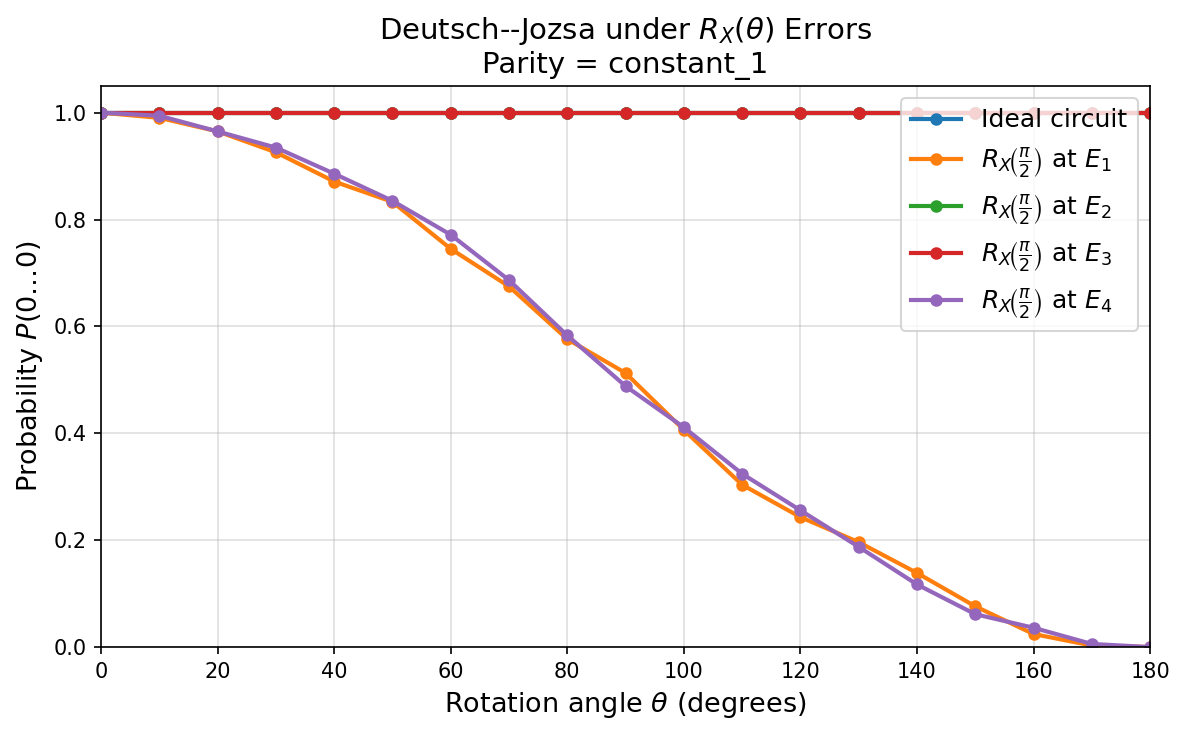

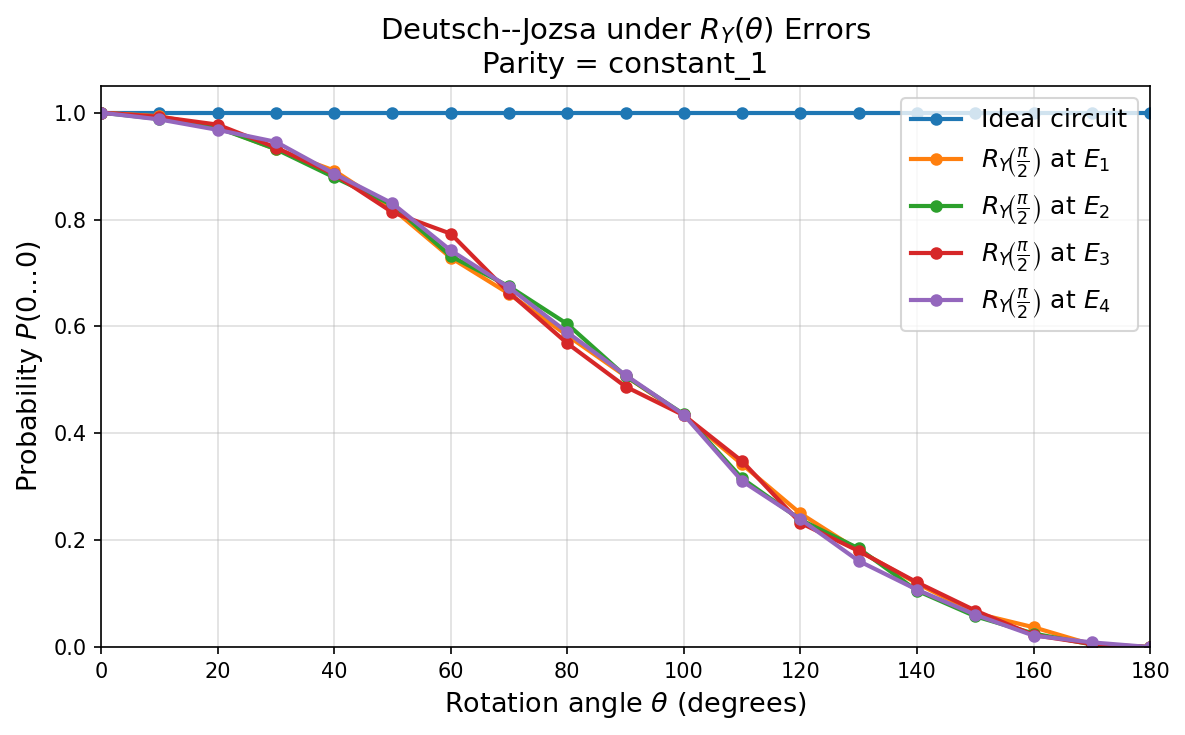

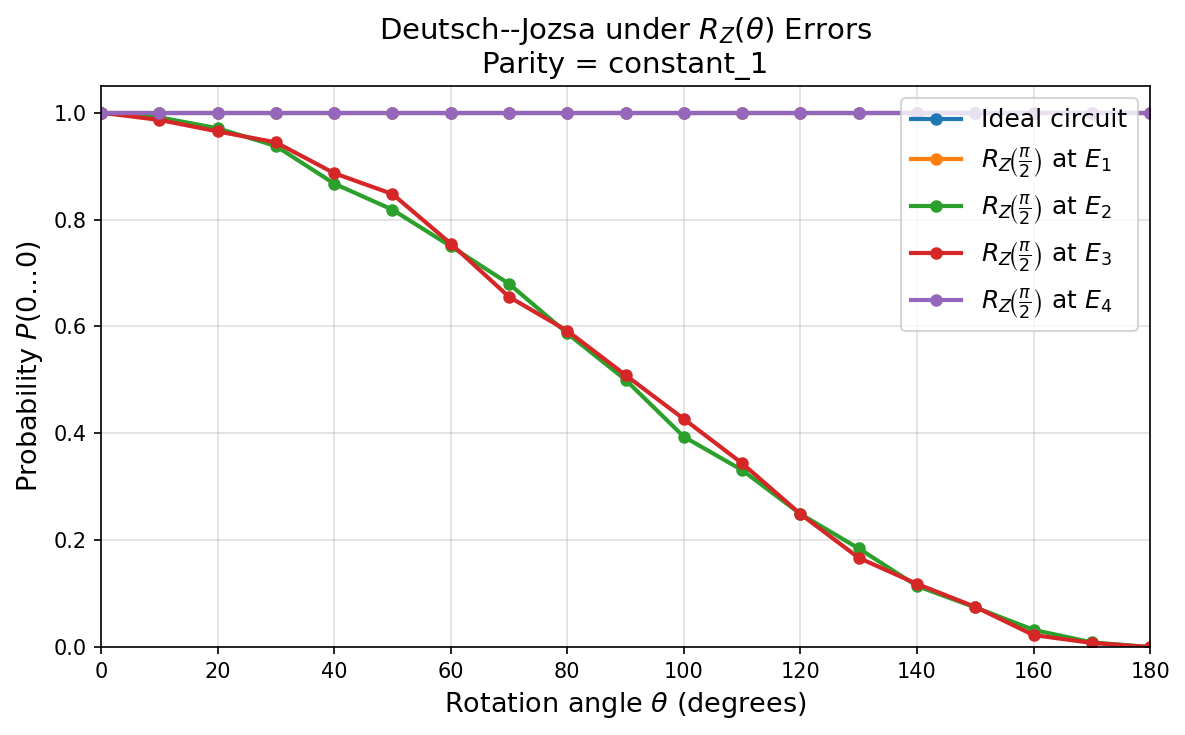

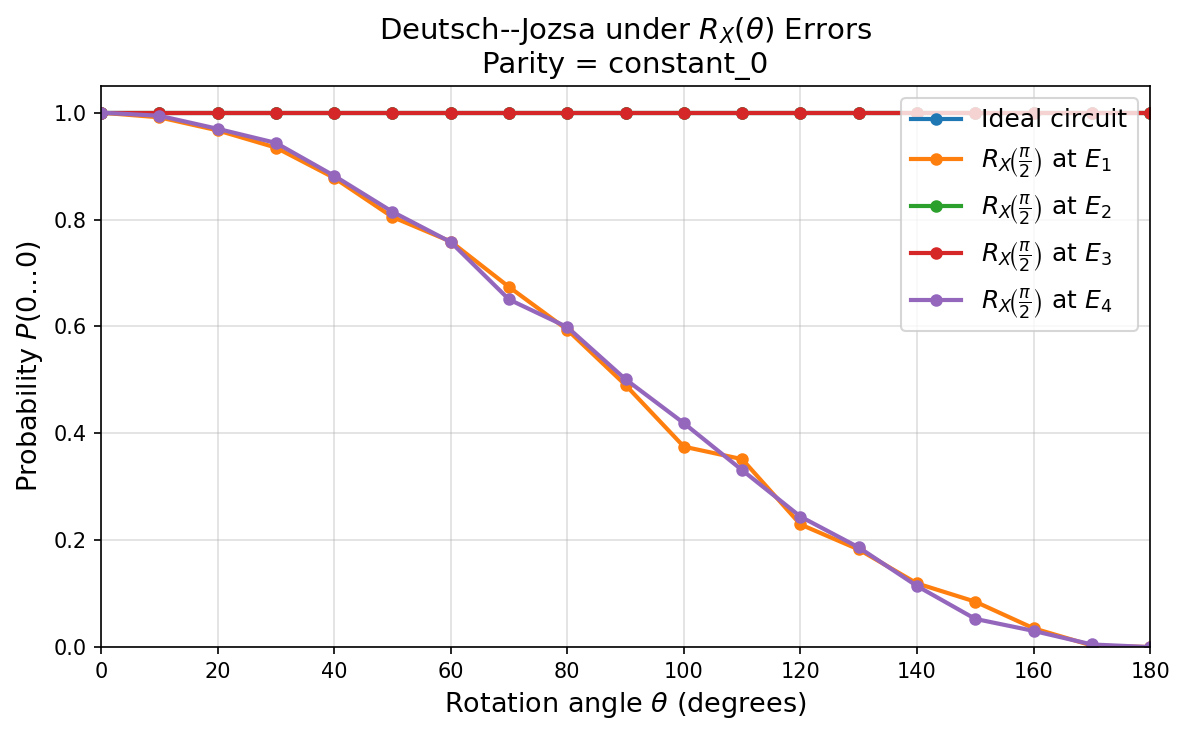

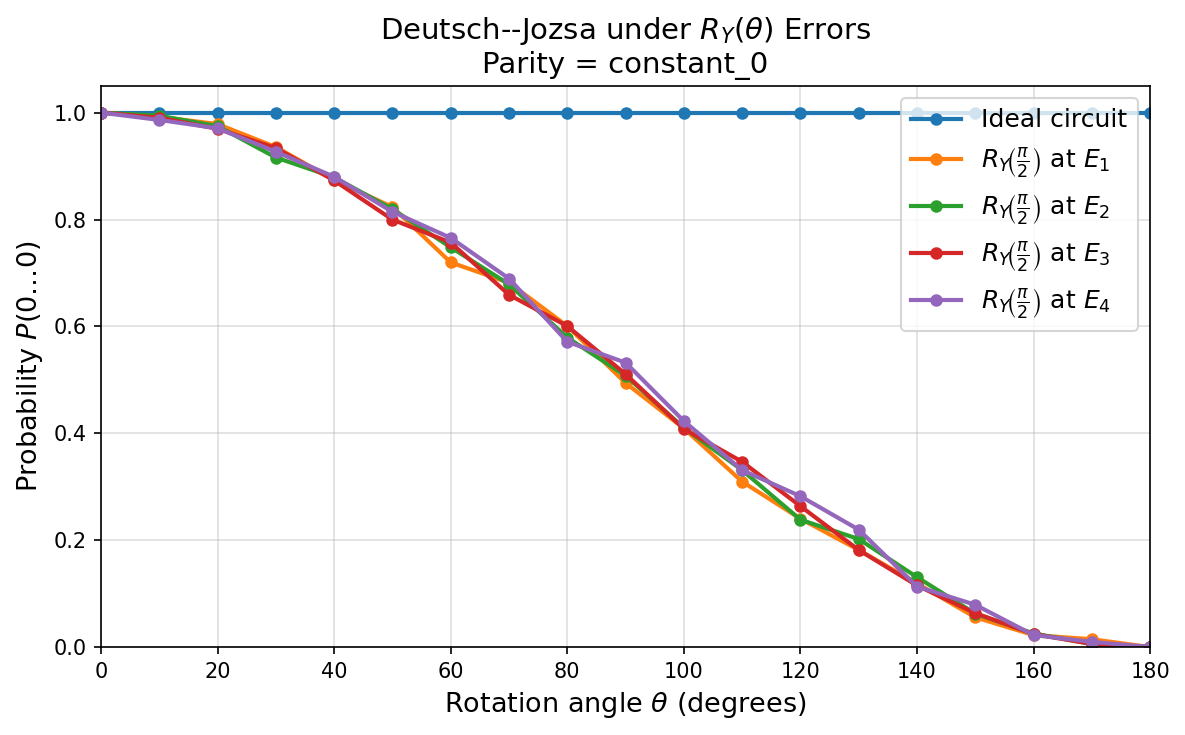

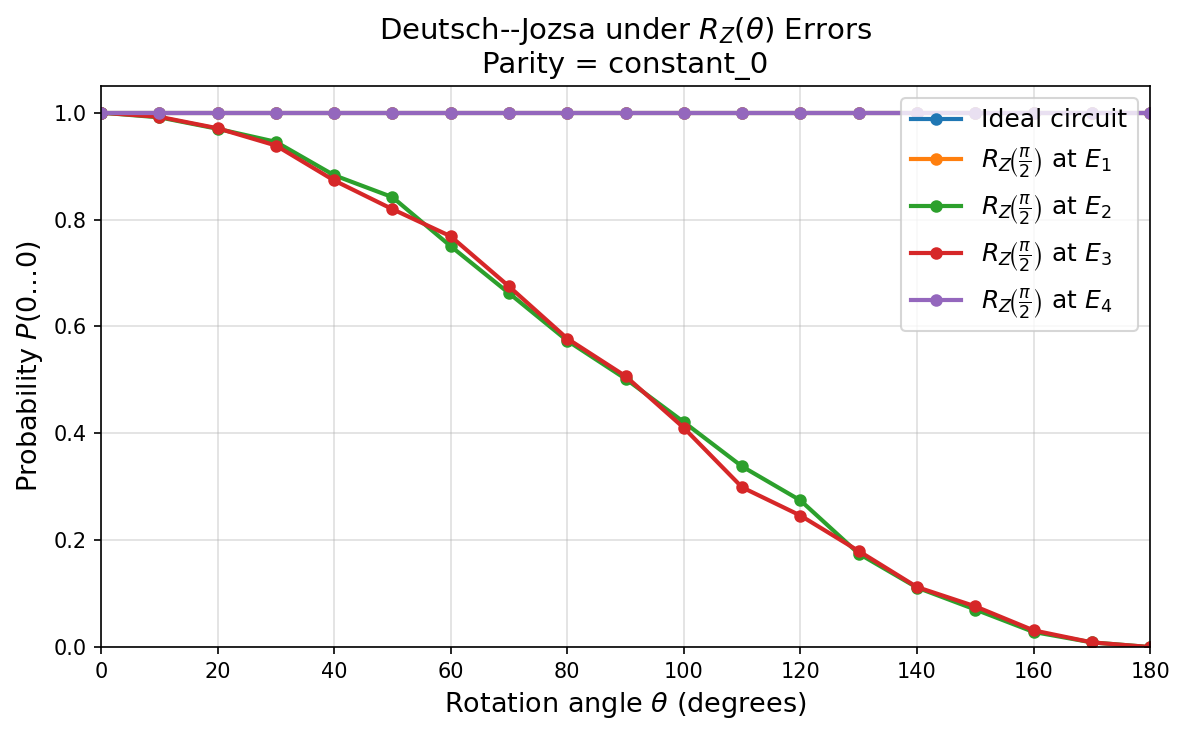

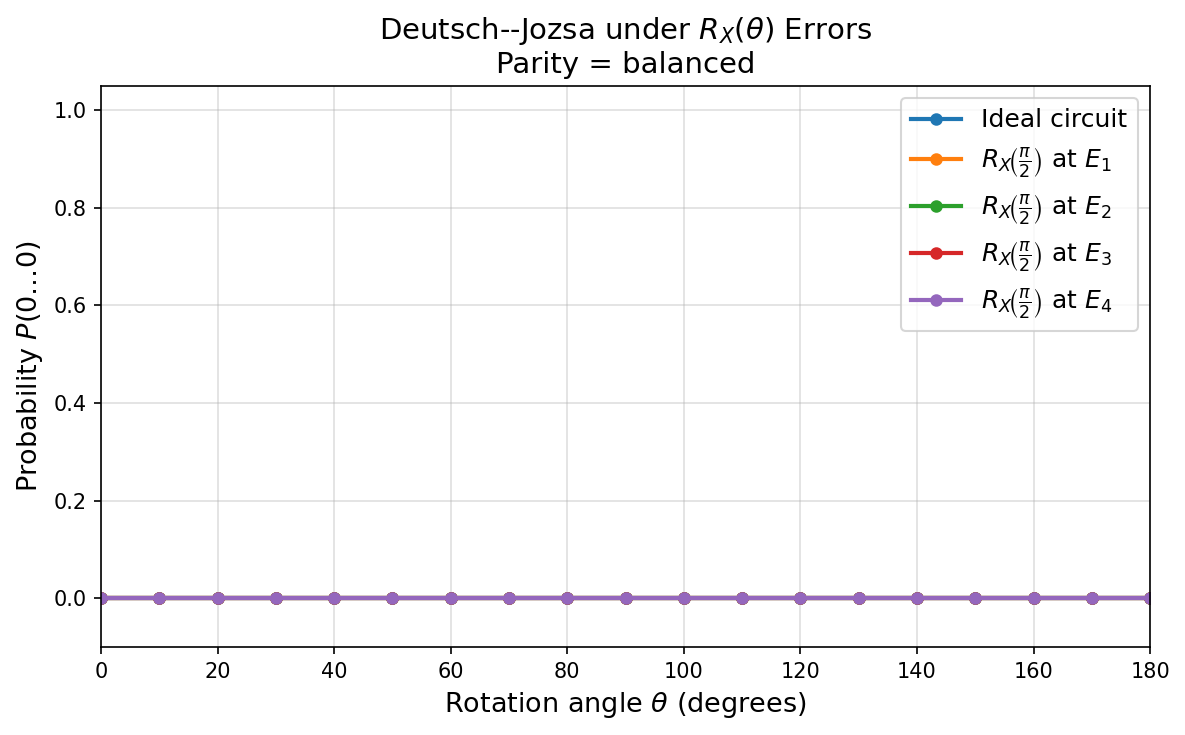

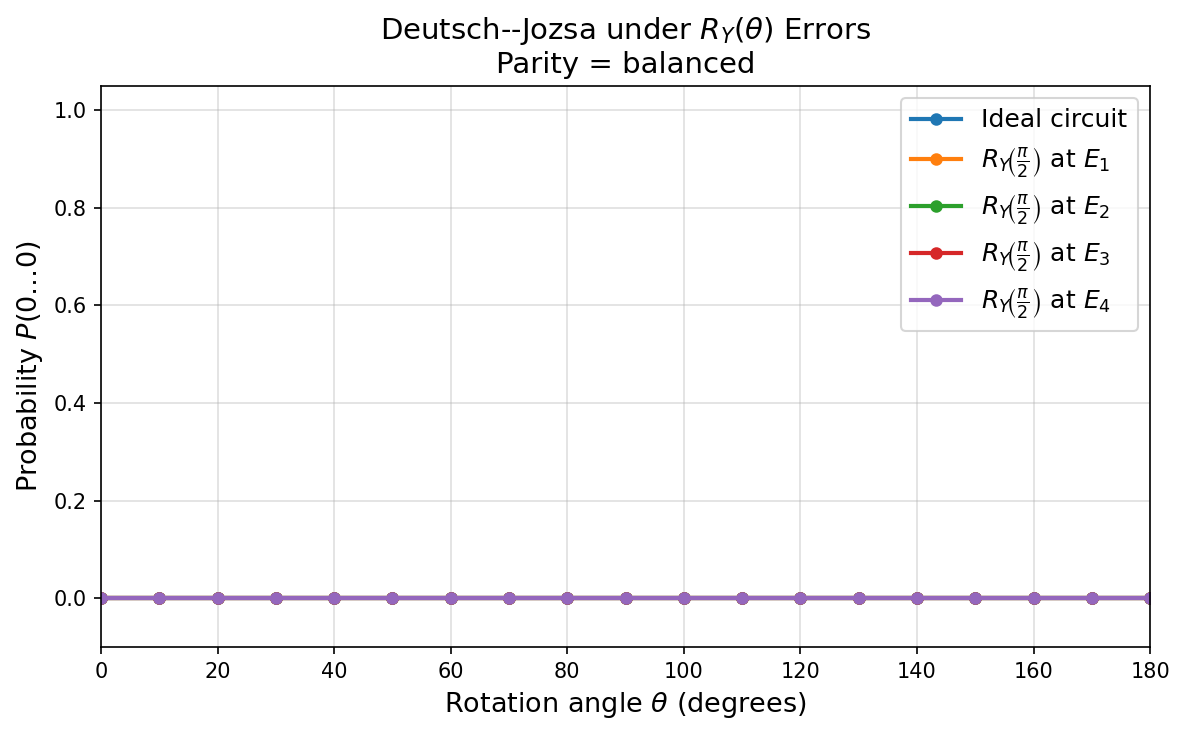

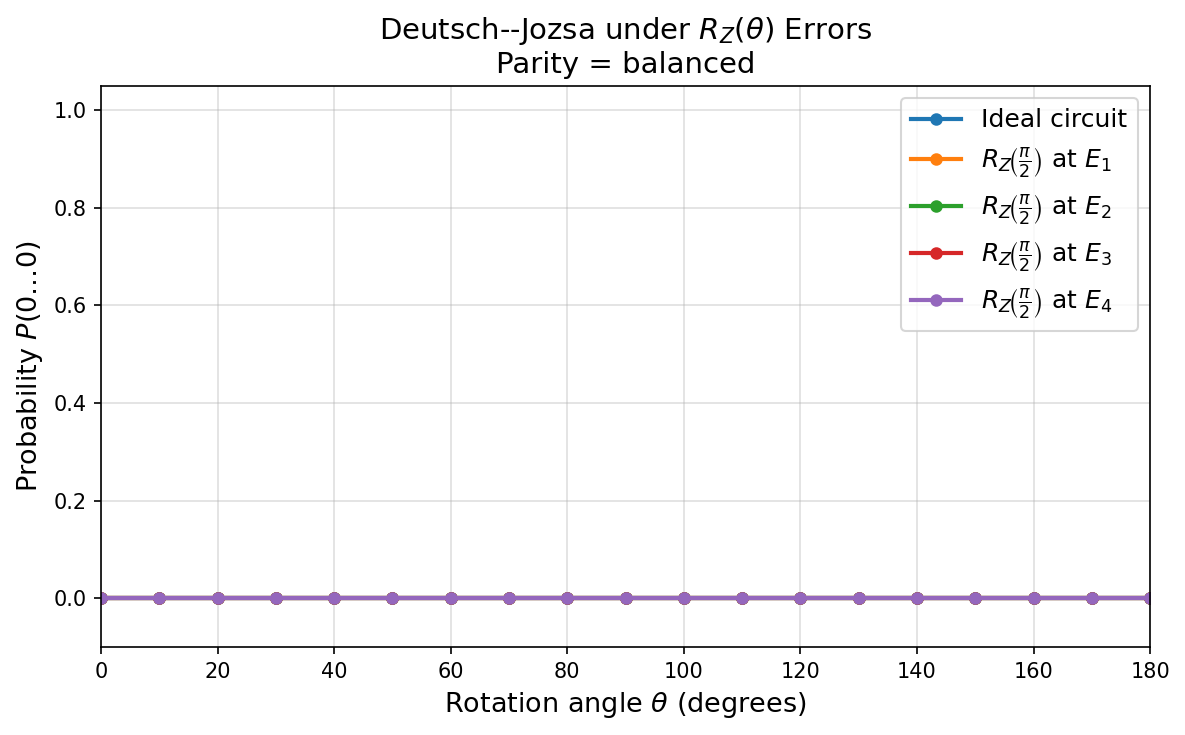

In [53]:
plot_error_positions(df, n_plot=9, axis_plot="X", function_plot="constant_1")

plot_error_positions(df, n_plot=9, axis_plot="Y", function_plot="constant_1")

plot_error_positions(df, n_plot=9, axis_plot="Z", function_plot="constant_1")

plot_error_positions(df, n_plot=9, axis_plot="X", function_plot="constant_0")

plot_error_positions(df, n_plot=9, axis_plot="Y", function_plot="constant_0")

plot_error_positions(df, n_plot=9, axis_plot="Z", function_plot="constant_0")

plot_error_positions(df, n_plot=9, axis_plot="X", function_plot="balanced")

plot_error_positions(df, n_plot=9, axis_plot="Y", function_plot="balanced")

plot_error_positions(df, n_plot=9, axis_plot="Z", function_plot="balanced")


The experiment investigates the effect of single-qubit rotation errors on the Deutsch–Jozsa Algorithm. Four error positions were considered: E1 before the first Hadamard gates, E2 after the first Hadamard gates, E3 after the oracle, and E4 after the final Hadamard gates. The rotation angle θ was varied from 0° to 180° in steps of 10°. For each circuit configuration, 4096 measurement shots were used to estimate the probability of measuring the all-zero input state.

The number of input qubits was selected as n = 1, 3, 5, 7, and 9. This interval provides a feasible range for simulation while still showing how the algorithm behaves as the system size increases. The middle qubit was selected as the target qubit for the rotation error. Results were collected for X, Y, and Z rotation axes and for both a constant function and a balanced parity function.

For the ideal Deutsch–Jozsa Algorithm, the constant function should produce a high probability of measuring the all-zero state, while the balanced function should produce a low probability of measuring the all-zero state. Any deviation from this ideal behaviour indicates how strongly the corresponding error position affects the algorithm.


In [46]:
"""leave the ideal circuit out.

The whole purpose of the sensitivity plot is already to show deviation from the ideal circuit.

The ideal circuit is implicitly represented by:

S(θ)=0

So you don't need a separate "Ideal" line. It would just be a flat line at zero and clutter the figure."""

def function_to_latex(function_plot):
    if function_plot == "constant_0":
        return r"\mathrm{constant}_0"
    elif function_plot == "constant_1":
        return r"\mathrm{constant}_1"
    elif function_plot == "balanced":
        return r"\mathrm{balanced}"
    else:
        return rf"\mathrm{{{function_plot}}}"


def error_label(error_pos, axis):
    if error_pos == "no_error":
        return "Ideal circuit"

    position_map = {
        "E1_before_H": "E_1",
        "E2_after_first_H": "E_2",
        "E3_after_oracle": "E_3",
        "E4_after_final_H": "E_4",
    }

    return rf"$R_{{{axis}}}\!\left(\frac{{\pi}}{{2}}\right)$ at ${position_map[error_pos]}$"

def add_ideal_reference(df):
    ideal = df[df["error_position"] == "no_error"][
        ["n", "theta_deg", "axis", "function", "P0"]
    ].rename(columns={"P0": "P0_ideal"})

    return df.merge(
        ideal,
        on=["n", "theta_deg", "axis", "function"],
        how="left"
    )
    
def plot_sensitivity(df, n_plot, axis_plot, function_plot):

    df2 = add_ideal_reference(df)

    plot_df = df2[
        (df2["n"] == n_plot) &
        (df2["axis"] == axis_plot) &
        (df2["function"] == function_plot) &
        (df2["error_position"] != "no_error")
    ].copy()

    plot_df["delta_P"] = np.abs(plot_df["P0"] - plot_df["P0_ideal"])

    plt.figure(figsize=(8, 5), dpi=150)

    axis = axis_plot.upper()

    for error_pos in [
        "E1_before_H",
        "E2_after_first_H",
        "E3_after_oracle",
        "E4_after_final_H",
    ]:
        subset = plot_df[plot_df["error_position"] == error_pos]

        if subset.empty:
            continue

        plt.plot(
            subset["theta_deg"],
            subset["delta_P"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=error_label(error_pos, axis)
        )

    function_label = function_plot

    plt.xlabel(r"Rotation angle $\theta$ (degrees)", fontsize=12)
    plt.ylabel(r"Sensitivity $|P_{\mathrm{error}} - P_{\mathrm{ideal}}|$", fontsize=12)

    plt.title(
    rf"Sensitivity to $R_{{{axis}}}(\theta)$ Errors"
    "\n"
    f"Parity = {function_label}",
    fontsize=13,
)

    if function_plot in ["constant_0", "constant_1"]:
        plt.ylim(0, 1.05)
    else:
        plt.ylim(-0.1, 1.05)

    plt.xlim(0, 180)
    plt.ylim(-0.05, 1.05)

    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()

    filename = f"sensitivity_{function_plot}_{axis_plot}_n{n_plot}.pdf"
    plt.savefig(filename, bbox_inches="tight", dpi=300)

    plt.show()
    plt.close()

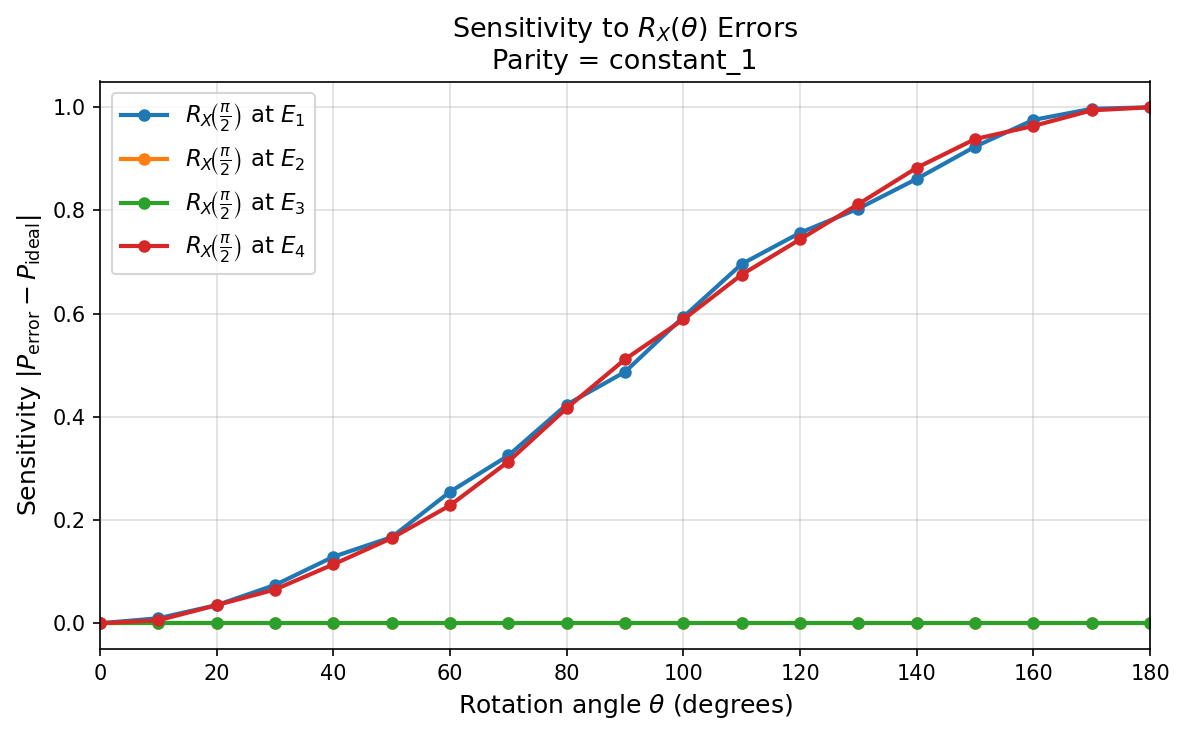

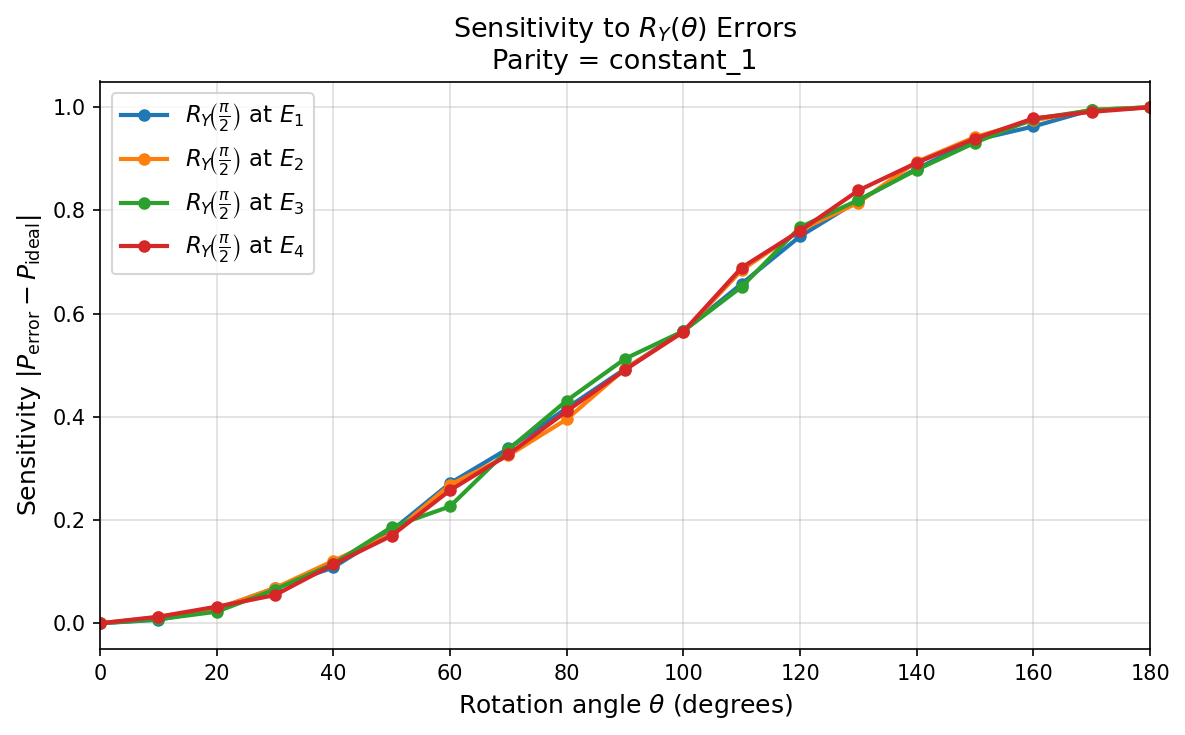

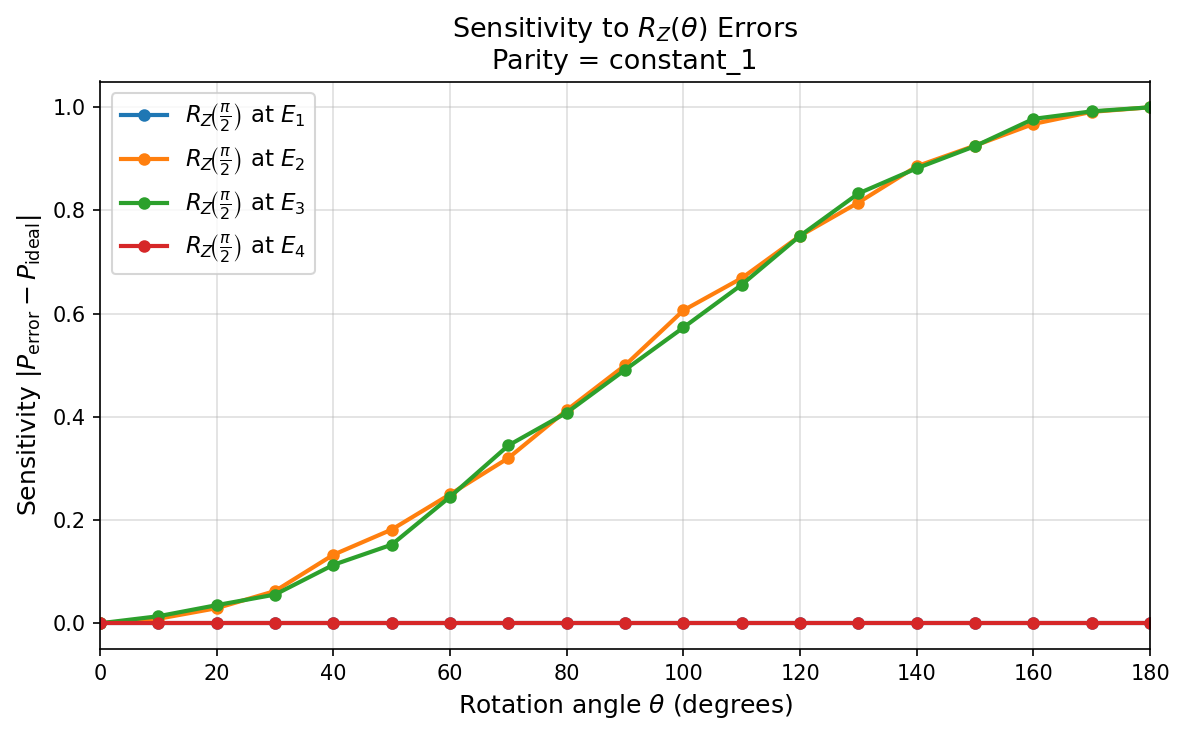

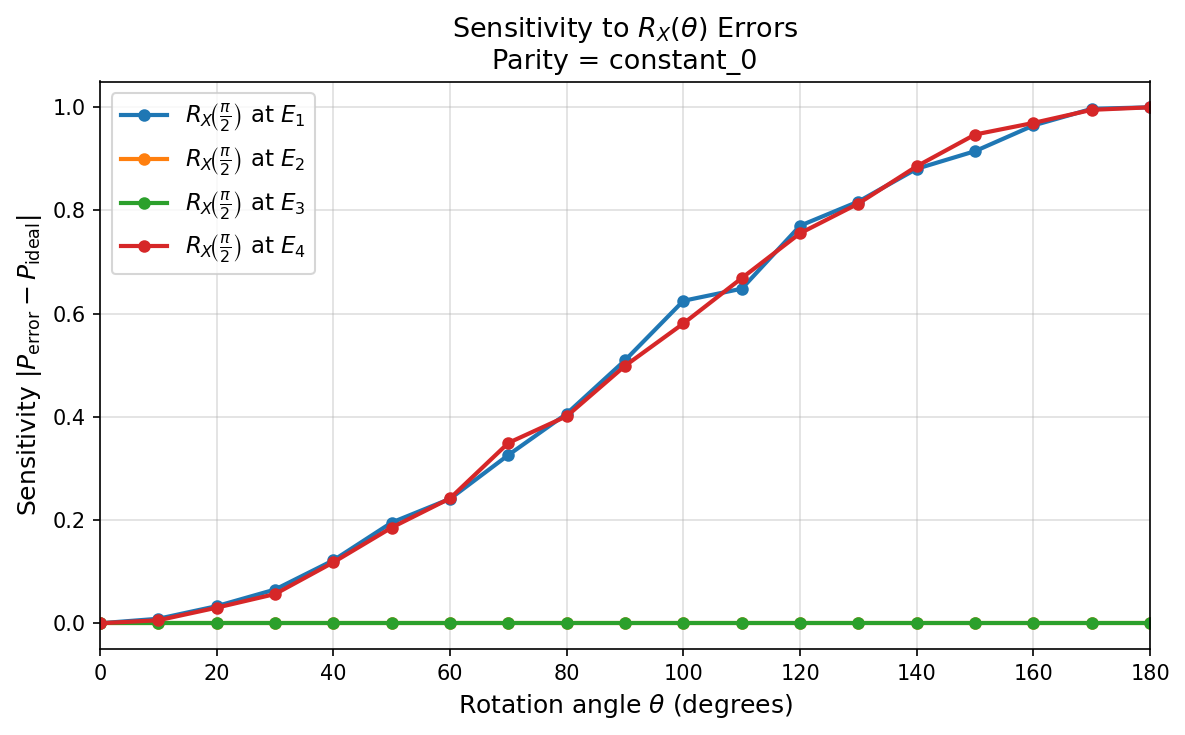

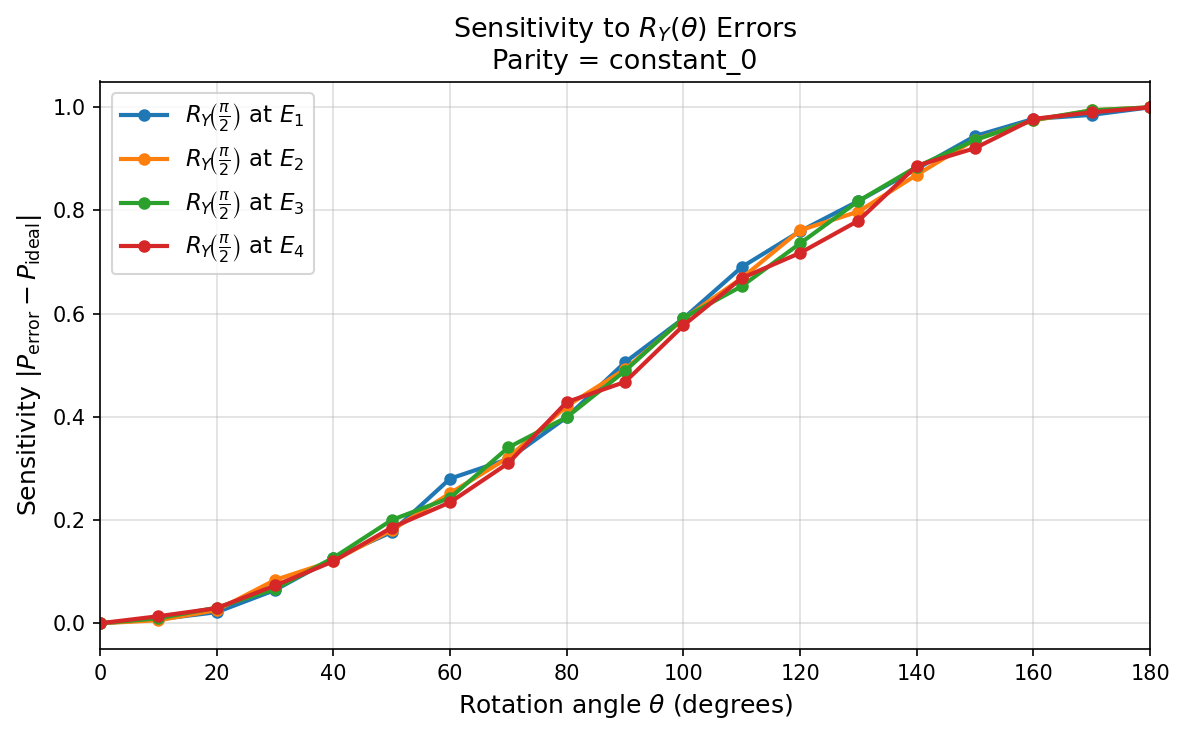

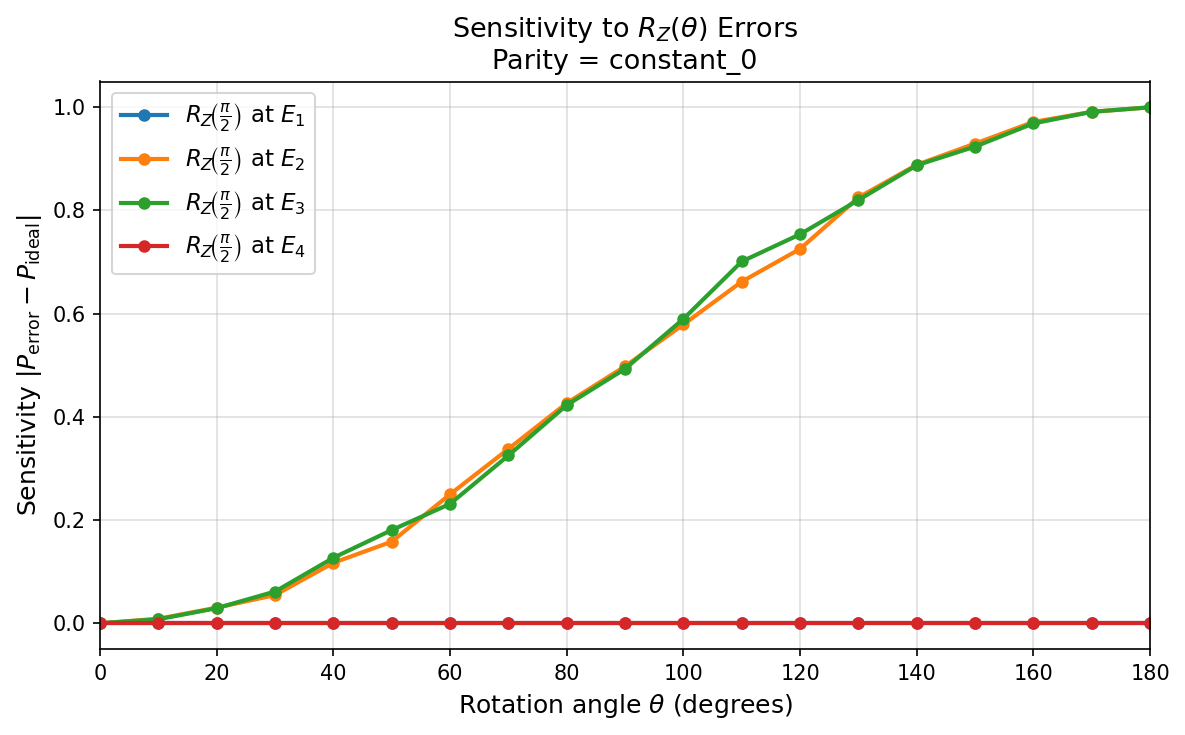

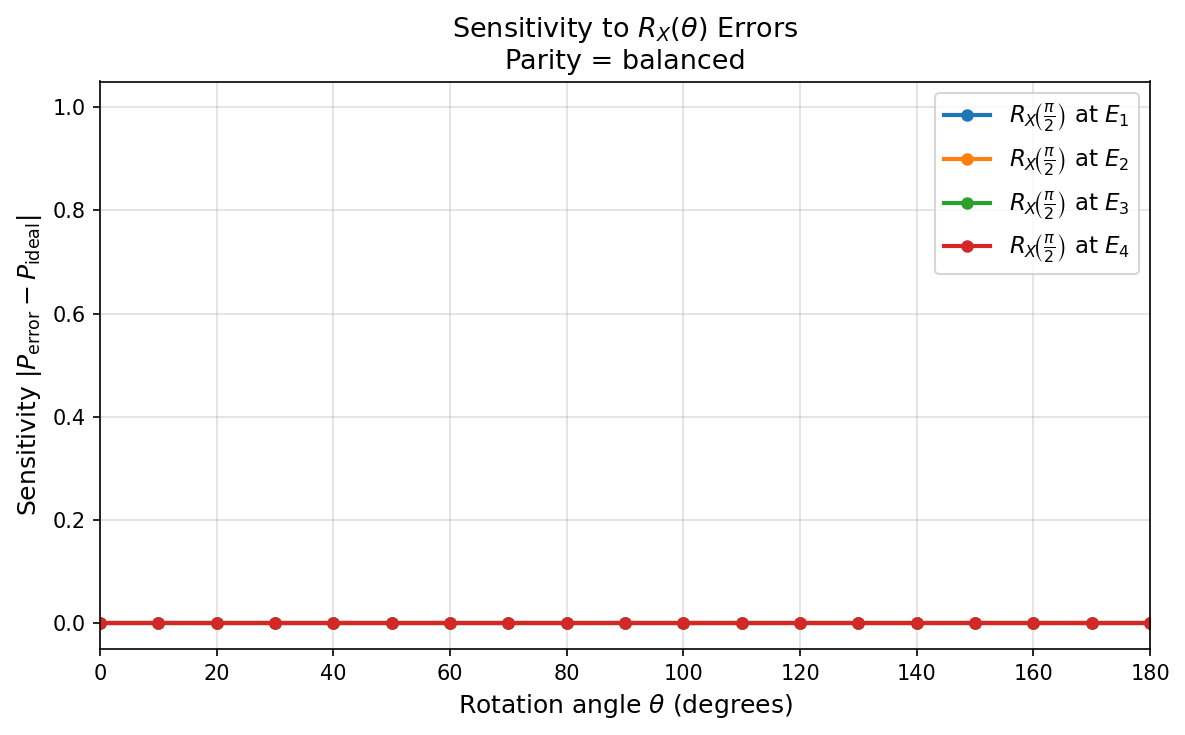

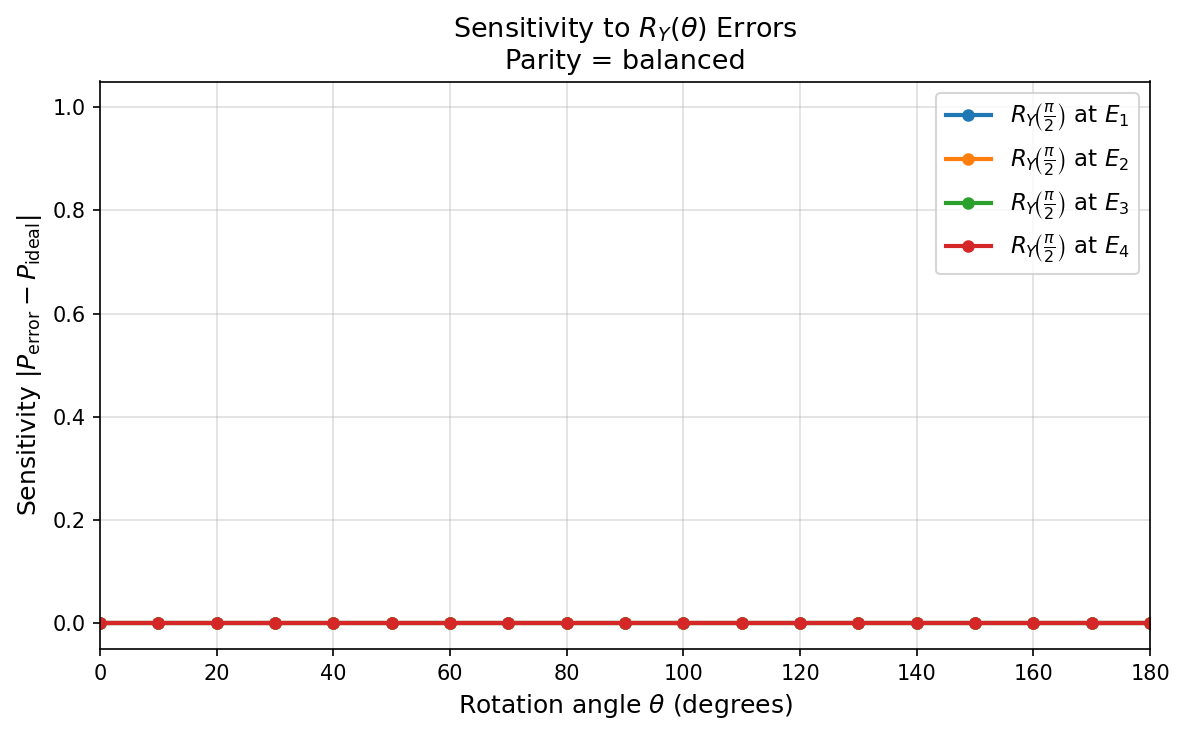

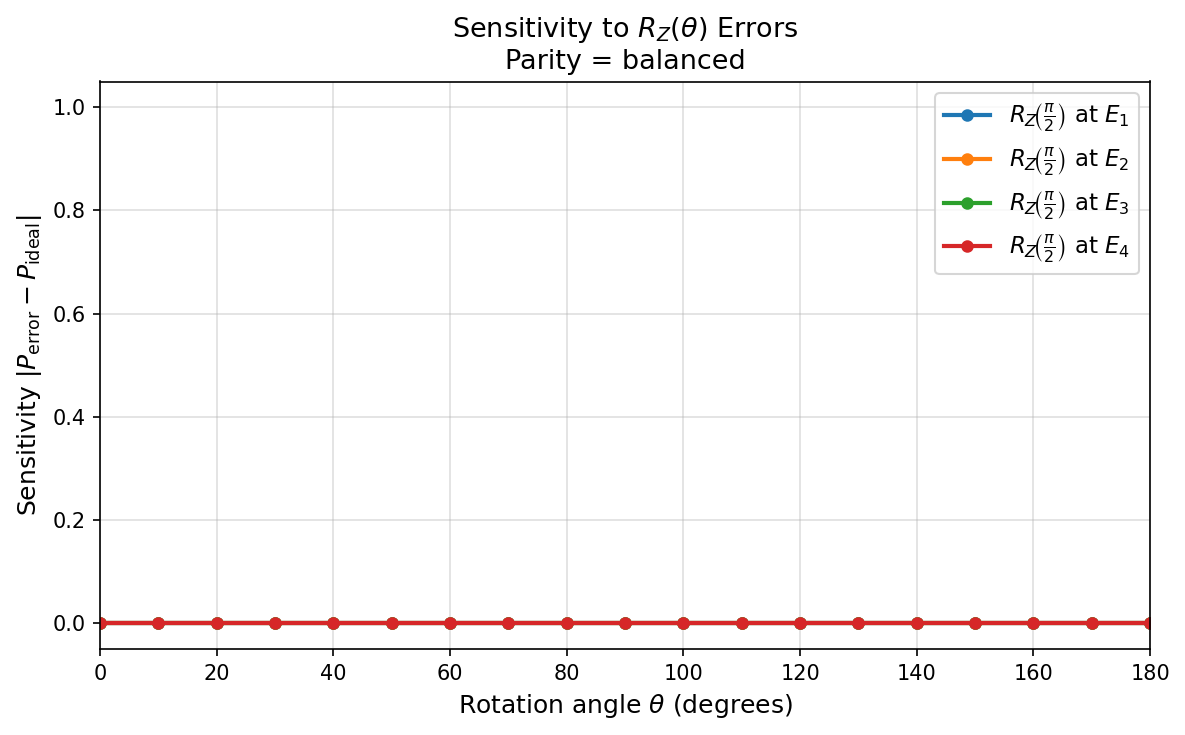

In [47]:
plot_sensitivity(df, n_plot=9, axis_plot="X", function_plot="constant_1")

plot_sensitivity(df, n_plot=9, axis_plot="Y", function_plot="constant_1")

plot_sensitivity(df, n_plot=9, axis_plot="Z", function_plot="constant_1")

plot_sensitivity(df, n_plot=9, axis_plot="X", function_plot="constant_0")

plot_sensitivity(df, n_plot=9, axis_plot="Y", function_plot="constant_0")

plot_sensitivity(df, n_plot=9, axis_plot="Z", function_plot="constant_0")

plot_sensitivity(df, n_plot=9, axis_plot="X", function_plot="balanced")
plot_sensitivity(df, n_plot=9, axis_plot="Y", function_plot="balanced")
plot_sensitivity(df, n_plot=9, axis_plot="Z", function_plot="balanced")
